# Helmet Detection — YOLOv8s Training & Evaluation

**Project:** Custom Object Detection System — Helmet Detection
**Model:** YOLOv8s (Ultralytics)
**Dataset:** 1,376 images, 2 classes (`With Helmet`, `Without Helmet`)

This notebook covers two stages:

1. **Model Training** — train YOLOv8s while experimenting with epochs, image size, batch size, and learning rate. All settings are recorded automatically by Ultralytics for every run.
2. **Evaluation** — evaluate the best-performing run using precision, recall, mAP50, mAP50-95, a confusion matrix, and sample predictions, followed by a strengths/weaknesses analysis.


## 1. Setup

In [1]:
# Install Ultralytics (YOLOv8) if not already installed
!pip install ultralytics --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 1.0 Upload Dataset (Google Colab only)

If you are running this notebook in **Google Colab**, run the cell below to upload your dataset zip (`Bike_Helmet_Detection_yolov8.zip`) directly. It will extract into a folder named `dataset` in the Colab working directory, matching the path expected by the rest of this notebook.

If you are running **locally** instead, skip this cell — just make sure your dataset is already extracted into a `dataset` folder next to this notebook.


In [3]:
from google.colab import files
import zipfile, os

# This opens a file picker — select your Bike_Helmet_Detection_yolov8.zip
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]  # gets the uploaded filename automatically

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted to:", os.path.abspath("dataset"))
print(os.listdir("dataset"))


Saving Bike Helmet Detection.yolov8.zip to Bike Helmet Detection.yolov8.zip
Extracted to: /content/dataset
['train', 'valid', 'data.yaml', 'test', 'README.dataset.txt', 'README.roboflow.txt']


In [4]:
import os

# Path to your dataset config (extracted from the Bike_Helmet_Detection_yolov8.zip you downloaded)
# Extract the zip into a folder named "dataset" next to this notebook, so the structure looks like:
#
#   your_project/
#   ├── Helmet_Detection_Training_Evaluation.ipynb
#   └── dataset/
#       ├── train/images, train/labels
#       ├── valid/images, valid/labels
#       ├── test/images,  test/labels
#       └── data.yaml
#
# If you extracted it somewhere else or under a different folder name, update the path below.
DATA_YAML = "dataset/data.yaml"

assert os.path.exists(DATA_YAML), f"data.yaml not found at {DATA_YAML} \n-> Extract your dataset zip into a folder named 'dataset' next to this notebook, or update DATA_YAML above."
print("Dataset config found:", DATA_YAML)


Dataset config found: dataset/data.yaml


### 1.1 Fixing the Dataset Paths (Roboflow known issue)

Roboflow YOLOv8 exports often write `train`/`val`/`test` as `../train/images`, `../valid/images`, `../test/images` inside `data.yaml`. This assumes a folder nesting that usually does not match how the dataset is actually extracted, and causes a "file not found" error at training time.

The cell below rewrites `data.yaml` to use a `path:` key pointing at the dataset's root folder, with `train`/`val`/`test` given as paths relative to that root. This makes the dataset work regardless of where the folder is placed, and only needs to be run once.


In [5]:
import yaml

dataset_root = os.path.dirname(os.path.abspath(DATA_YAML))

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

cfg["path"] = dataset_root
cfg["train"] = "train/images"
cfg["val"] = "valid/images"
cfg["test"] = "test/images"

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("Fixed data.yaml contents:")
print(yaml.safe_dump(cfg, sort_keys=False))


Fixed data.yaml contents:
train: train/images
val: valid/images
test: test/images
nc: 2
names:
- With Helmet
- Without Helmet
roboflow:
  workspace: muhammad-hassan-uewvy
  project: bike-helmet-detection-2vdjo-nkdyo-gy7ko
  version: dataset
  license: Public Domain
  url: https://universe.roboflow.com/muhammad-hassan-uewvy/bike-helmet-detection-2vdjo-nkdyo-gy7ko/dataset/dataset
path: /content/dataset



### 1.2 Sanity Check — Confirm Every Split Resolves Correctly

In [6]:
for split_key, split_name in [("train", "train"), ("val", "valid"), ("test", "test")]:
    images_path = os.path.join(cfg["path"], cfg[split_key])
    labels_path = images_path.replace("images", "labels")
    n_images = len(os.listdir(images_path)) if os.path.exists(images_path) else 0
    n_labels = len(os.listdir(labels_path)) if os.path.exists(labels_path) else 0
    status = "OK" if n_images > 0 and n_images == n_labels else "CHECK THIS"
    print(f"{split_name:6s} | images: {n_images:5d} | labels: {n_labels:5d} | {status}")


train  | images:  1185 | labels:  1185 | OK
valid  | images:   127 | labels:   127 | OK
test   | images:    64 | labels:    64 | OK


## 2. Model Training

We train **YOLOv8s** starting from pretrained COCO weights (transfer learning) and run five experiments, varying one hyperparameter at a time from a common baseline. Each run is saved under a unique name so results are never overwritten, and Ultralytics automatically records every setting used (see `args.yaml` inside each run folder).

| Run | Epochs | Image Size | Batch Size | Learning Rate (lr0) | Purpose |
|---|---|---|---|---|---|
| run1_baseline | 15 | 640 | 16 | 0.01 | Default reference point |
| run2_epochs100 | 20 | 640 | 16 | 0.01 | Test effect of more epochs |
| run3_imgsz416 | 15 | 416 | 16 | 0.01 | Test smaller image size (speed vs. small-object accuracy) |
| run4_batch8 | 15 | 640 | 8 | 0.01 | Test smaller batch size |
| run5_lr0.001 | 15 | 640 | 16 | 0.001 | Test slower learning rate |


In [7]:
# Define the experiment matrix
experiments = [
    {"name": "run1_baseline",   "epochs": 15,  "imgsz": 640, "batch": 16, "lr0": 0.01},
    {"name": "run2_epochs100",  "epochs": 20, "imgsz": 640, "batch": 16, "lr0": 0.01},
    {"name": "run3_imgsz416",   "epochs": 15,  "imgsz": 416, "batch": 16, "lr0": 0.01},
    {"name": "run4_batch8",     "epochs": 15,  "imgsz": 640, "batch": 8,  "lr0": 0.01},
    {"name": "run5_lr0.001",    "epochs": 15,  "imgsz": 640, "batch": 16, "lr0": 0.001},
]
for e in experiments:
    print(e)


{'name': 'run1_baseline', 'epochs': 15, 'imgsz': 640, 'batch': 16, 'lr0': 0.01}
{'name': 'run2_epochs100', 'epochs': 20, 'imgsz': 640, 'batch': 16, 'lr0': 0.01}
{'name': 'run3_imgsz416', 'epochs': 15, 'imgsz': 416, 'batch': 16, 'lr0': 0.01}
{'name': 'run4_batch8', 'epochs': 15, 'imgsz': 640, 'batch': 8, 'lr0': 0.01}
{'name': 'run5_lr0.001', 'epochs': 15, 'imgsz': 640, 'batch': 16, 'lr0': 0.001}


In [8]:
# Run all experiments sequentially.
# NOTE: this will take a long time on CPU. On a GPU (e.g. Google Colab), this is much faster.
# You can also run experiments one cell at a time instead of in a loop if you prefer to inspect results between runs.

run_results = []

for exp in experiments:
    print(f"\n{'='*60}\nStarting {exp['name']}\n{'='*60}")
    model = YOLO("yolov8s.pt")  # fresh pretrained weights for every run
    results = model.train(
        data=DATA_YAML,
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        batch=exp["batch"],
        lr0=exp["lr0"],
        name=exp["name"],
        exist_ok=True,
    )
    run_results.append({"name": exp["name"], "save_dir": str(results.save_dir)})

run_results



Starting run1_baseline
Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1_baseline, nbs=64

[{'name': 'run1_baseline', 'save_dir': '/content/runs/detect/run1_baseline'},
 {'name': 'run2_epochs100', 'save_dir': '/content/runs/detect/run2_epochs100'},
 {'name': 'run3_imgsz416', 'save_dir': '/content/runs/detect/run3_imgsz416'},
 {'name': 'run4_batch8', 'save_dir': '/content/runs/detect/run4_batch8'},
 {'name': 'run5_lr0.001', 'save_dir': '/content/runs/detect/run5_lr0.001'}]

### 2.1 Recorded Settings and Metrics per Run

Ultralytics writes a `results.csv` file into each run's folder with per-epoch metrics. We read the **final epoch** row of each run to build a single comparison table — this is the definitive record of "settings + outcome" for every experiment.


In [9]:
def load_final_metrics(save_dir, exp):
    csv_path = os.path.join(save_dir, "results.csv")
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]
    return {
        "Run": exp["name"],
        "Epochs": exp["epochs"],
        "Image Size": exp["imgsz"],
        "Batch Size": exp["batch"],
        "Learning Rate": exp["lr0"],
        "Precision": round(last.get("metrics/precision(B)", float("nan")), 4),
        "Recall": round(last.get("metrics/recall(B)", float("nan")), 4),
        "mAP50": round(last.get("metrics/mAP50(B)", float("nan")), 4),
        "mAP50-95": round(last.get("metrics/mAP50-95(B)", float("nan")), 4),
    }

summary_rows = []
for exp, r in zip(experiments, run_results):
    summary_rows.append(load_final_metrics(r["save_dir"], exp))

summary_df = pd.DataFrame(summary_rows)
summary_df


,Run,Epochs,Image Size,Batch Size,Learning Rate,Precision,Recall,mAP50,mAP50-95
0,run1_baseline,15,640,16,0.010,0.7976,0.7032,0.7859,0.4019
1,run2_epochs100,20,640,16,0.010,0.7755,0.6933,0.7534,0.4012
2,run3_imgsz416,15,416,16,0.010,0.7315,0.7232,0.7613,0.4239
3,run4_batch8,15,640,8,0.010,0.7438,0.7243,0.7517,0.4090
4,run5_lr0.001,15,640,16,0.001,0.7976,0.7032,0.7859,0.4019


In [10]:
# Save the comparison table for the report
summary_df.to_csv("training_experiments_summary.csv", index=False)
print("Saved: training_experiments_summary.csv")
summary_df


Saved: training_experiments_summary.csv


,Run,Epochs,Image Size,Batch Size,Learning Rate,Precision,Recall,mAP50,mAP50-95
0,run1_baseline,15,640,16,0.010,0.7976,0.7032,0.7859,0.4019
1,run2_epochs100,20,640,16,0.010,0.7755,0.6933,0.7534,0.4012
2,run3_imgsz416,15,416,16,0.010,0.7315,0.7232,0.7613,0.4239
3,run4_batch8,15,640,8,0.010,0.7438,0.7243,0.7517,0.4090
4,run5_lr0.001,15,640,16,0.001,0.7976,0.7032,0.7859,0.4019


### 2.2 Visual Comparison Across Runs

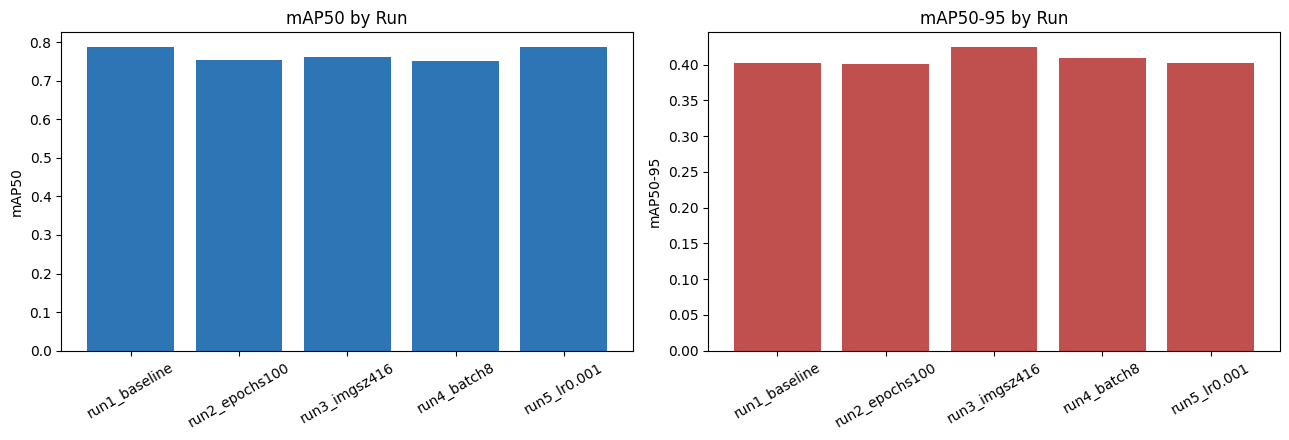

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(summary_df["Run"], summary_df["mAP50"], color="#2E75B6")
axes[0].set_title("mAP50 by Run")
axes[0].set_ylabel("mAP50")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(summary_df["Run"], summary_df["mAP50-95"], color="#C0504D")
axes[1].set_title("mAP50-95 by Run")
axes[1].set_ylabel("mAP50-95")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("training_experiments_comparison.png", dpi=150)
plt.show()


In [12]:
# Identify the best run by mAP50-95 (the stricter, more informative metric)
best_row = summary_df.loc[summary_df["mAP50-95"].idxmax()]
best_run_name = best_row["Run"]
print("Best run:", best_run_name)
best_row


Best run: run3_imgsz416


,2
Run,run3_imgsz416
Epochs,15
Image Size,416
Batch Size,16
Learning Rate,0.01
Precision,0.7315
Recall,0.7232
mAP50,0.7613
mAP50-95,0.4239


## 3. Evaluation

We now evaluate the **best run** (selected above by mAP50-95) in detail: precision, recall, mAP50, mAP50-95, a confusion matrix, and sample predictions on held-out test images.


In [13]:
best_weights = os.path.join("runs/detect", best_run_name, "weights", "best.pt")
assert os.path.exists(best_weights), f"Weights not found at {best_weights}"

best_model = YOLO(best_weights)
print("Loaded best model from:", best_weights)


Loaded best model from: runs/detect/run3_imgsz416/weights/best.pt


### 3.0 Save Trained Model to Google Drive (so you don't have to retrain every session)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

save_dir = "/content/drive/MyDrive/helmet_detection_model"
os.makedirs(save_dir, exist_ok=True)

shutil.copy(best_weights, os.path.join(save_dir, "best.pt"))
print("Model saved to:", os.path.join(save_dir, "best.pt"))


Mounted at /content/drive
Model saved to: /content/drive/MyDrive/helmet_detection_model/best.pt


### 3.1 Precision, Recall, mAP50, mAP50-95 (on the test set)

In [16]:
metrics = best_model.val(data=DATA_YAML, split="test")

print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")
print(f"mAP50       : {metrics.box.map50:.4f}")
print(f"mAP50-95    : {metrics.box.map:.4f}")


Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 9.6±5.4 MB/s, size: 32.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/dataset/test/labels... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 366.7it/s 0.2s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7it/s 2.4s
                   all         64        187      0.826      0.734      0.829      0.449
           With Helmet         48        124      0.881      0.834      0.922      0.544
        Without Helmet         25         63       0.77      0.635      0.736      0.354
Speed: 3.4ms preprocess, 7

In [17]:
# Per-class breakdown (With Helmet vs Without Helmet)
class_names = best_model.names
for i, name in class_names.items():
    print(f"{name:15s} | mAP50: {metrics.box.maps[i]:.4f}")


With Helmet     | mAP50: 0.5441
Without Helmet  | mAP50: 0.3545


### 3.2 Confusion Matrix

Ultralytics automatically saves a `confusion_matrix.png` inside the validation run folder during `.val()`. We display it directly below.


Confusion matrix saved at: /content/runs/detect/val/confusion_matrix.png


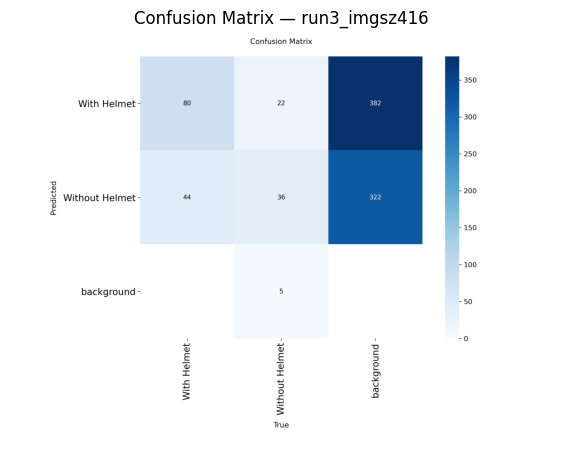

In [18]:
val_dir = metrics.save_dir
cm_path = os.path.join(val_dir, "confusion_matrix.png")
print("Confusion matrix saved at:", cm_path)

from PIL import Image
img = Image.open(cm_path)
plt.figure(figsize=(7, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Confusion Matrix — {best_run_name}")
plt.show()


### 3.3 Sample Predictions

Run inference on a handful of test images and visualize the predicted bounding boxes, class labels, and confidence scores.


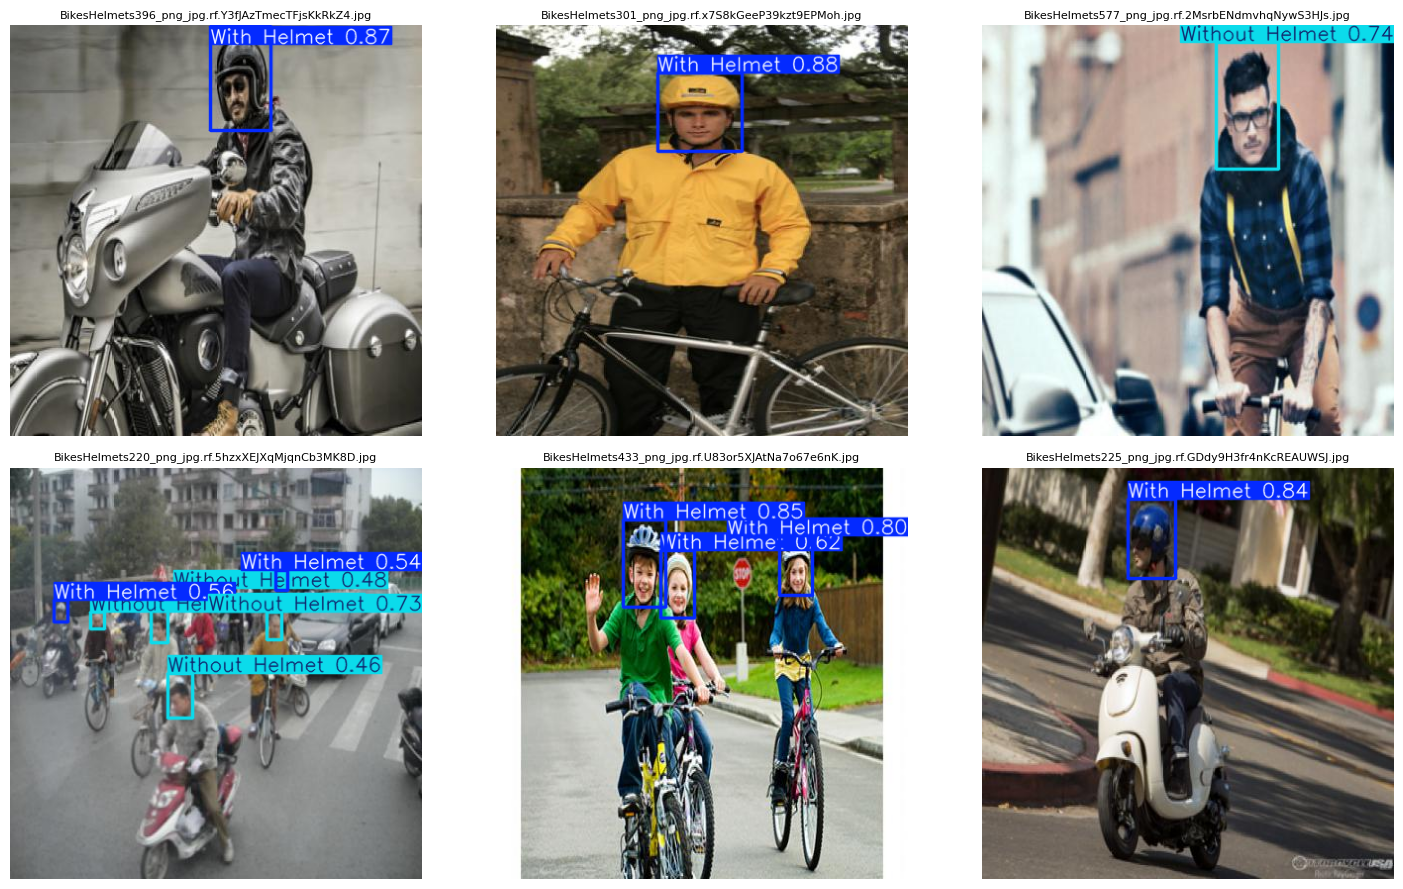

In [19]:
import glob, random

test_images_dir = os.path.join(cfg["path"], cfg["test"])
test_images = glob.glob(os.path.join(test_images_dir, "*.jpg"))
assert len(test_images) > 0, f"No test images found in {test_images_dir}"

random.seed(42)
sample_images = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flatten(), sample_images):
    result = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    annotated = result.plot()  # returns a BGR numpy array with boxes drawn
    annotated_rgb = annotated[..., ::-1]
    ax.imshow(annotated_rgb)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path), fontsize=8)

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()


## 4. Analysis: Strengths and Weaknesses

Use the metrics and visuals produced above to fill in this analysis. Some guiding questions are provided — replace the placeholders with your actual observations once the cells above have been run.

**Strengths** (edit based on your results):
- *(e.g., "The model achieves strong mAP50 on the majority class ('With Helmet'), reflecting the larger number of training instances for this class.")*
- *(e.g., "Detections on medium-to-large, unoccluded riders are consistently accurate across sample predictions.")*

**Weaknesses** (edit based on your results):
- *(e.g., "Recall on the minority class ('Without Helmet') is lower than precision, suggesting the model misses some non-compliant riders — consistent with the ~1.95:1 class imbalance identified during dataset preparation.")*
- *(e.g., "The confusion matrix shows a notable number of 'Without Helmet' instances misclassified as background/missed entirely, likely for small or heavily occluded riders.")*
- *(e.g., "Sample predictions show reduced confidence scores on riders captured at a distance, where the helmet occupies very few pixels.")*

**Suggested next steps:**
- Consider class-weighted loss or oversampling the minority class to address the imbalance identified above.
- Add more self-captured images specifically of small/occluded/distant riders to strengthen the weakest cases.
- Evaluate whether a higher input resolution (e.g., `imgsz=960`) improves small-object recall, at the cost of slower inference.


### 4.1 Load Trained Model from Google Drive (skip retraining next time)

In [36]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO

best_model = YOLO("/content/drive/MyDrive/helmet_detection_model/hugging best.pt")
print("Loaded trained helmet detection model from Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded trained helmet detection model from Google Drive.


## 5. Deployment: Interactive Helmet Detection App

This section wraps the trained model in a **Gradio** app with everything needed for a demo / hand-off:

- **Image Upload** — detect helmets in a single uploaded image
- **Video Upload** — run detection over every frame of an uploaded video and export the annotated result
- **Webcam Detection** — live, real-time detection from the browser webcam
- **Confidence Threshold Slider** — adjust the detection confidence cutoff on the fly
- **Detection Statistics** — number of objects, processing time, and confidence scores for every run
- **Export Results** — download the annotated image / video

Run the cells below in order. The last cell launches the app (use `share=True` to get a public link, e.g. on Colab).

In [29]:
# Install Gradio (only needed once per environment)
!pip install gradio --quiet


In [37]:
import os
import time
import glob

import cv2
import numpy as np
import gradio as gr
from PIL import Image
from ultralytics import YOLO

# Make sure we have a trained model in memory even if this section is run
# standalone (e.g. after a kernel restart) instead of right after training/loading.
try:
    best_model
    print("Using 'best_model' already loaded in this session.")
except NameError:
    # Fall back to the best weights saved by the training loop above,
    # in case Drive wasn't mounted/loaded either.
    candidate_weights = sorted(glob.glob("runs/detect/*/weights/best.pt"))
    assert candidate_weights, (
        "No trained model found in memory or under runs/detect/*/weights/best.pt. "
        "Run the training section above, or run the 'Load Trained Model from Google "
        "Drive' cell first."
    )
    best_weights = candidate_weights[-1]
    best_model = YOLO(best_weights)
    print("Loaded model from:", best_weights)

APP_OUTPUT_DIR = "app_outputs"
os.makedirs(APP_OUTPUT_DIR, exist_ok=True)


Using 'best_model' already loaded in this session.


### 5.1 Shared helpers — stats formatting & annotated-image saving

In [38]:
def format_detection_stats(result, elapsed_seconds, extra_lines=None):
    """Build a Markdown summary: object count, processing time, confidence scores."""
    boxes = result.boxes
    n_objects = len(boxes)

    if n_objects == 0:
        conf_line = "N/A (no detections)"
    else:
        confs = boxes.conf.cpu().numpy()
        conf_line = ", ".join(f"{c:.2f}" for c in confs)

    lines = [
        f"**Objects detected:** {n_objects}",
        f"**Processing time:** {elapsed_seconds * 1000:.1f} ms",
        f"**Confidence scores:** {conf_line}",
    ]
    if extra_lines:
        lines.extend(extra_lines)
    return "\n\n".join(lines)


def save_annotated_image(annotated_rgb_array, prefix="image"):
    ts = int(time.time() * 1000)
    out_path = os.path.join(APP_OUTPUT_DIR, f"{prefix}_{ts}.png")
    Image.fromarray(annotated_rgb_array).save(out_path)
    return out_path


### 5.2 Image Upload detection

In [39]:
def detect_on_image(image, conf_threshold):
    """Run detection on a single uploaded image.

    Returns: annotated image (for display), stats markdown, downloadable file path.
    """
    if image is None:
        return None, "Upload an image to run detection.", None

    t0 = time.time()
    result = best_model.predict(image, conf=conf_threshold, verbose=False)[0]
    elapsed = time.time() - t0

    annotated_bgr = result.plot()          # numpy array, BGR
    annotated_rgb = annotated_bgr[..., ::-1]

    stats_md = format_detection_stats(result, elapsed)
    out_path = save_annotated_image(annotated_rgb, prefix="image")

    return annotated_rgb, stats_md, out_path


### 5.3 Video Upload detection

In [40]:
def detect_on_video(video_path, conf_threshold, progress=gr.Progress(track_tqdm=False)):
    """Run detection frame-by-frame over an uploaded video and export the annotated video.

    Returns: path to annotated video (for playback/export), stats markdown.
    """
    if video_path is None:
        return None, "Upload a video to run detection."

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None

    ts = int(time.time() * 1000)
    out_path = os.path.join(APP_OUTPUT_DIR, f"video_{ts}.mp4")
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    total_objects = 0
    all_confs = []
    frame_idx = 0
    t0 = time.time()

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        result = best_model.predict(frame, conf=conf_threshold, verbose=False)[0]
        writer.write(result.plot())

        n = len(result.boxes)
        total_objects += n
        if n > 0:
            all_confs.extend(result.boxes.conf.cpu().numpy().tolist())

        frame_idx += 1
        if total_frames:
            progress(min(frame_idx / total_frames, 1.0), desc="Processing video")

    elapsed = time.time() - t0
    cap.release()
    writer.release()

    avg_conf = f"{np.mean(all_confs):.2f}" if all_confs else "N/A"
    processing_fps = frame_idx / elapsed if elapsed > 0 else 0.0

    stats_md = "\n\n".join([
        f"**Frames processed:** {frame_idx}",
        f"**Total objects detected:** {total_objects}",
        f"**Processing time:** {elapsed:.2f} s ({processing_fps:.1f} FPS)",
        f"**Average confidence score:** {avg_conf}",
    ])

    return out_path, stats_md


### 5.4 Webcam detection (real-time)

`gr.Image(sources=["webcam"], streaming=True)` streams frames from the browser webcam to the function below as
fast as the browser sends them, so detections update live. Confidence scores/object counts refresh on every frame.

In [41]:
def detect_on_webcam_frame(frame, conf_threshold):
    """Called continuously with live webcam frames. Returns annotated frame + live stats."""
    if frame is None:
        return None, "Waiting for webcam feed..."

    t0 = time.time()
    result = best_model.predict(frame, conf=conf_threshold, verbose=False)[0]
    elapsed = time.time() - t0

    annotated_rgb = result.plot()[..., ::-1]
    stats_md = format_detection_stats(result, elapsed, extra_lines=["**Mode:** live webcam stream"])

    return annotated_rgb, stats_md


### 5.5 Build and launch the app

In [42]:
with gr.Blocks(title="Helmet Detection App") as demo:
    gr.Markdown(
        "# 🪖 Helmet Detection App\n"
        "Upload an image or video, or use your webcam, to detect **With Helmet** / **Without Helmet** riders. "
        "Adjust the confidence threshold per tab and export annotated results."
    )

    with gr.Tabs():
        # ---------------- Image tab ----------------
        with gr.Tab("Image Upload"):
            with gr.Row():
                with gr.Column():
                    image_input = gr.Image(type="numpy", label="Upload image")
                    image_conf = gr.Slider(0.0, 1.0, value=0.25, step=0.01,
                                            label="Confidence threshold")
                    image_button = gr.Button("Run Detection", variant="primary")
                with gr.Column():
                    image_output = gr.Image(type="numpy", label="Annotated result")
                    image_stats = gr.Markdown(label="Detection statistics")
                    image_file = gr.File(label="Export annotated image")

            image_button.click(
                fn=detect_on_image,
                inputs=[image_input, image_conf],
                outputs=[image_output, image_stats, image_file],
            )

        # ---------------- Video tab ----------------
        with gr.Tab("Video Upload"):
            with gr.Row():
                with gr.Column():
                    video_input = gr.Video(label="Upload video")
                    video_conf = gr.Slider(0.0, 1.0, value=0.25, step=0.01,
                                            label="Confidence threshold")
                    video_button = gr.Button("Run Detection", variant="primary")
                with gr.Column():
                    video_output = gr.Video(label="Annotated result (downloadable)")
                    video_stats = gr.Markdown(label="Detection statistics")

            video_button.click(
                fn=detect_on_video,
                inputs=[video_input, video_conf],
                outputs=[video_output, video_stats],
            )

        # ---------------- Webcam tab ----------------
        with gr.Tab("Webcam Detection"):
            with gr.Row():
                with gr.Column():
                    webcam_input = gr.Image(sources=["webcam"], streaming=True,
                                             type="numpy", label="Webcam feed")
                    webcam_conf = gr.Slider(0.0, 1.0, value=0.25, step=0.01,
                                             label="Confidence threshold")
                with gr.Column():
                    webcam_output = gr.Image(type="numpy", label="Live annotated feed")
                    webcam_stats = gr.Markdown(label="Detection statistics")

            webcam_input.stream(
                fn=detect_on_webcam_frame,
                inputs=[webcam_input, webcam_conf],
                outputs=[webcam_output, webcam_stats],
            )

if __name__ == "__main__":
    # share=True gives a public URL (useful on Colab); set to False for local-only.
    demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8b2a41d736922b94a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
